# REAL-WORLD RETAIL DATA SCIENCE PROJECT
# Sales Analysis & Prediction

In [ ]:
Project Description

Retail Sales Analysis and Prediction using Machine Learning is a real-world data science project that analyzes superstore sales data to identify business trends and predict future sales. The project includes data cleaning, exploratory data analysis (EDA), visualization, and machine learning using Python libraries like Pandas, Matplotlib, and Scikit-learn. The goal is to generate meaningful insights and improve decision-making through predictive analytics.

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

### 2. LOAD DATASET

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

# Display first 5 rows
print("First 5 Rows of Dataset")
print(df.head())

First 5 Rows of Dataset
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category

### 3. DATA UNDERSTANDING

In [3]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape:
(9994, 21)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null  

### 4. DATA CLEANING

In [4]:
# Convert Order Date into datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)


Shape After Removing Duplicates:
(9994, 21)


### 5. FEATURE ENGINEERING

In [5]:
# Create Month and Year columns
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

 ### 6. EXPLORATORY DATA ANALYSIS

#### Monthly Sales Trend

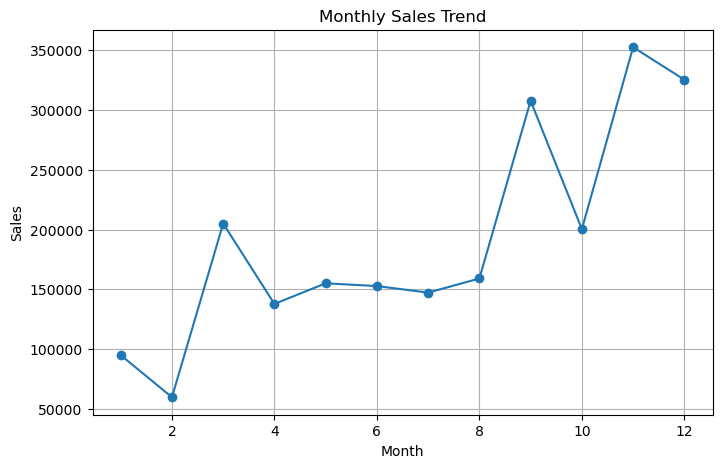

In [6]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)

plt.show()


#### Sales by Category

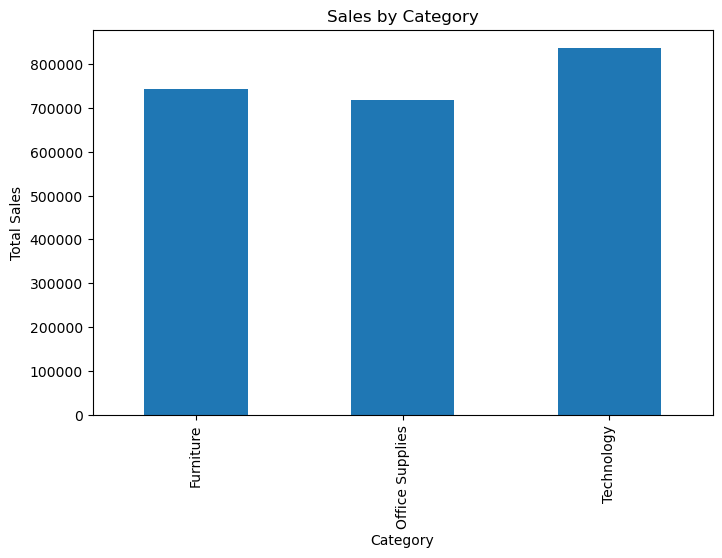

In [7]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

#### Profit by Region

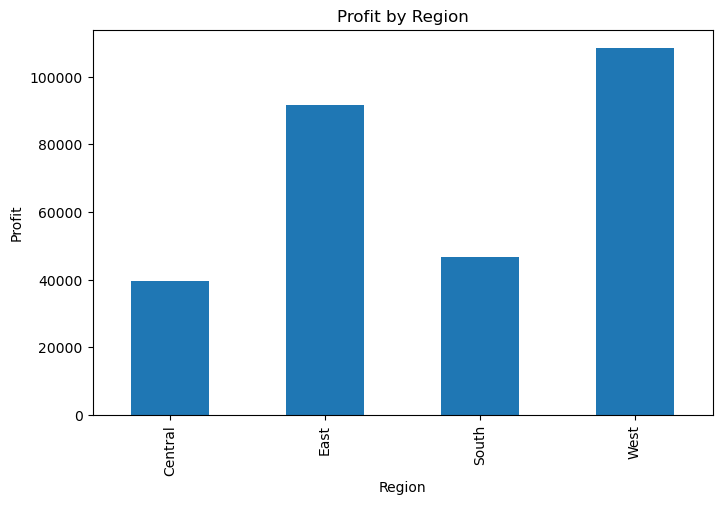

In [8]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()

#### Top 10 Sub-Categories

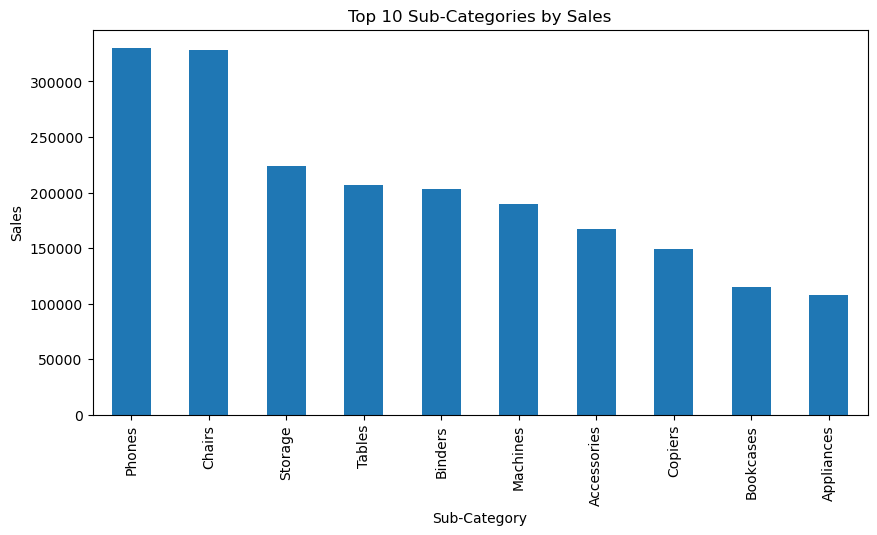

In [9]:

top_subcategory = df.groupby('Sub-Category')['Sales'].sum() \
                    .sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_subcategory.plot(kind='bar')

plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.show()

### 7. MACHINE LEARNING

In [11]:
# Select Features
X = df[['Quantity', 'Discount', 'Profit', 'Month']]

# Target Variable
y = df['Sales']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



### 8. TRAIN MODEL

In [12]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 9. PREDICTIONS

In [13]:

predictions = model.predict(X_test)

### 10. MODEL EVALUATION

In [14]:
mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("\n=========================")
print("MODEL PERFORMANCE")
print("=========================")

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)


MODEL PERFORMANCE
Mean Absolute Error: 108.36942453643485
R2 Score: 0.555286806410805


### 11. ACTUAL VS PREDICTED

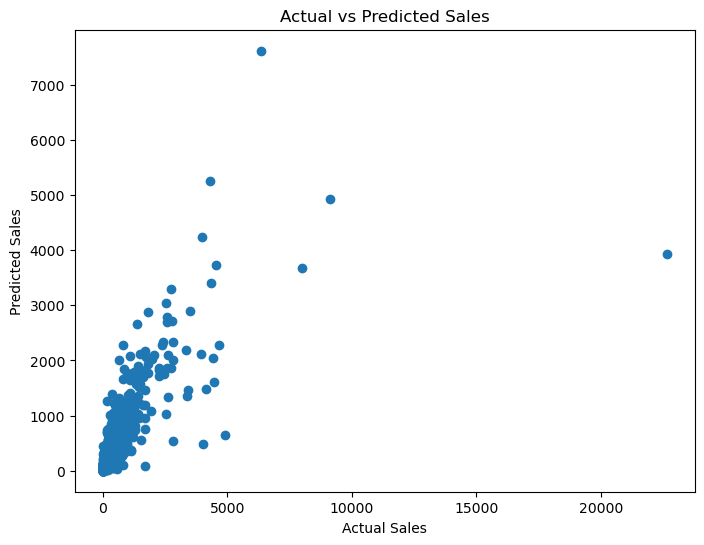

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.show()

### 12. FEATURE IMPORTANCE

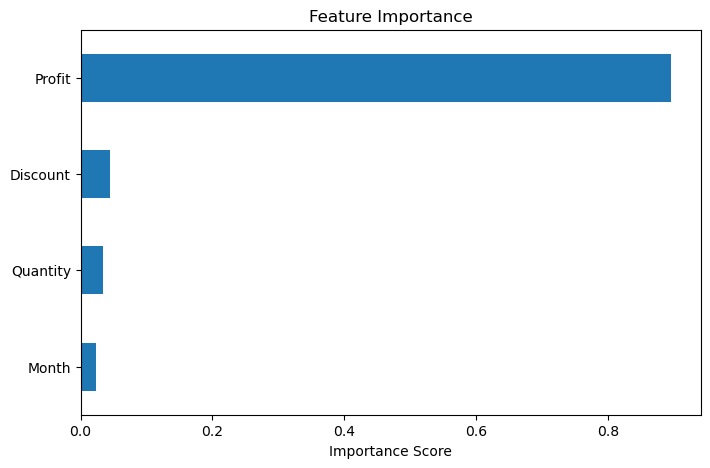

In [16]:

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

### 13. BUSINESS INSIGHTS


In [17]:

print("\n=========================")
print("BUSINESS INSIGHTS")
print("=========================")

print("""
1. Technology and Office Supplies contribute high sales.

2. Some regions generate more profit than others.

3. Seasonal trends affect sales performance.

4. Discount impacts overall profitability.

5. Machine Learning model can predict future sales effectively.
""")


BUSINESS INSIGHTS

1. Technology and Office Supplies contribute high sales.

2. Some regions generate more profit than others.

3. Seasonal trends affect sales performance.

4. Discount impacts overall profitability.

5. Machine Learning model can predict future sales effectively.

